In [7]:
%pip install scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 8.0 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 KB 10.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Detailed confusion analysis
def analyze_disagreements(annotator1_labels, annotator2_labels):
    """Analyze where annotators disagree"""
    
    # Get all unique labels
    all_labels = sorted(set(annotator1_labels + annotator2_labels))
    
    # Confusion matrix
    cm = confusion_matrix(annotator1_labels, annotator2_labels, labels=all_labels)
    
    print("\\n=== Confusion Matrix Analysis ===")
    print("Rows: Annotator 1 (validated), Columns: Annotator 2 (non-validated)")
    
    # Create DataFrame for better display
    cm_df = pd.DataFrame(cm, index=all_labels, columns=all_labels)
    print(cm_df)
    
    # Find most common disagreements
    disagreements = []
    for i, label1 in enumerate(all_labels):
        for j, label2 in enumerate(all_labels):
            if i != j and cm[i][j] > 0:
                disagreements.append((label1, label2, cm[i][j]))
    
    # Sort by frequency
    disagreements.sort(key=lambda x: x[2], reverse=True)
    
    print("\\n=== Top 10 Disagreement Patterns ===")
    print("(Annotator1 -> Annotator2: Count)")
    for label1, label2, count in disagreements[:10]:
        percentage = (count / len(annotator1_labels)) * 100
        print(f"{label1} -> {label2}: {count} ({percentage:.2f}%)")
    
    return cm_df, disagreements

# Analyze disagreements
confusion_matrix_df, disagreement_patterns = analyze_disagreements(annotator1_labels, annotator2_labels)

# Classification report
print("\\n=== Classification Report ===")
print(classification_report(annotator1_labels, annotator2_labels, zero_division=0))

In [ ]:
# Calculate Cohen's kappa score
def calculate_kappa_scores(annotator1_labels, annotator2_labels):
    """Calculate Cohen's kappa with detailed analysis"""
    
    # Overall Cohen's kappa
    overall_kappa = cohen_kappa_score(annotator1_labels, annotator2_labels)
    
    # Calculate agreement statistics
    total_labels = len(annotator1_labels)
    agreements = sum(1 for a1, a2 in zip(annotator1_labels, annotator2_labels) if a1 == a2)
    agreement_percentage = (agreements / total_labels) * 100
    
    # Calculate kappa for different label groups
    # Group 1: All labels
    # Group 2: Only named entity labels (exclude OTHERS, GARBAGE, SKIP)
    non_entity_labels = {'OTHERS', 'GARBAGE', 'SKIP'}
    
    entity_only_labels_1 = []
    entity_only_labels_2 = []
    
    for a1, a2 in zip(annotator1_labels, annotator2_labels):
        if a1 not in non_entity_labels or a2 not in non_entity_labels:
            entity_only_labels_1.append(a1)
            entity_only_labels_2.append(a2)
    
    entity_kappa = cohen_kappa_score(entity_only_labels_1, entity_only_labels_2) if entity_only_labels_1 else 0
    
    return {
        'overall_kappa': overall_kappa,
        'entity_kappa': entity_kappa,
        'total_tokens': total_labels,
        'agreements': agreements,
        'agreement_percentage': agreement_percentage,
        'entity_tokens': len(entity_only_labels_1)
    }

# Calculate kappa scores
kappa_results = calculate_kappa_scores(annotator1_labels, annotator2_labels)

print("=== Cohen's Kappa Analysis ===")
print(f"Overall Cohen's Kappa: {kappa_results['overall_kappa']:.4f}")
print(f"Entity-focused Kappa: {kappa_results['entity_kappa']:.4f}")
print(f"Raw Agreement: {kappa_results['agreement_percentage']:.2f}% ({kappa_results['agreements']}/{kappa_results['total_tokens']})")
print(f"Total tokens analyzed: {kappa_results['total_tokens']:,}")
print(f"Entity-relevant tokens: {kappa_results['entity_tokens']:,}")

# Interpretation of kappa values
def interpret_kappa(kappa):
    if kappa < 0:
        return "Poor (worse than chance)"
    elif kappa < 0.20:
        return "Slight"
    elif kappa < 0.40:
        return "Fair"
    elif kappa < 0.60:
        return "Moderate"
    elif kappa < 0.80:
        return "Substantial"
    else:
        return "Almost Perfect"

print(f"\\nKappa Interpretation:")
print(f"Overall Agreement: {interpret_kappa(kappa_results['overall_kappa'])}")
print(f"Entity Agreement: {interpret_kappa(kappa_results['entity_kappa'])}")

In [ ]:
# Format annotations for Cohen's kappa calculation
def prepare_annotations_for_kappa(validated_sentences, non_validated_sentences, common_ids):
    """Prepare annotation data for kappa calculation"""
    
    annotator1_labels = []  # validated 
    annotator2_labels = []  # non-validated
    
    total_tokens = 0
    mismatched_sentences = 0
    
    for sentence_id in common_ids:
        val_tags = validated_sentences[sentence_id]['tags']
        non_val_tags = non_validated_sentences[sentence_id]['tags']
        
        # Get all words from both annotations
        val_words = set(val_tags.keys())
        non_val_words = set(non_val_tags.keys())
        
        # Check if sentences have same words (they should)
        if val_words != non_val_words:
            mismatched_sentences += 1
            continue
        
        # Get labels for each word in consistent order
        words = sorted(val_words)  # Sort for consistency
        
        for word in words:
            annotator1_labels.append(val_tags[word])
            annotator2_labels.append(non_val_tags[word])
            total_tokens += 1
    
    print(f"Processed {len(common_ids)} sentences")
    print(f"Mismatched sentences (different words): {mismatched_sentences}")
    print(f"Total tokens for kappa calculation: {total_tokens}")
    
    return annotator1_labels, annotator2_labels

# Prepare the data
annotator1_labels, annotator2_labels = prepare_annotations_for_kappa(
    validated_sentences, non_validated_sentences, common_ids_list
)

print(f"Annotator 1 labels: {len(annotator1_labels)}")
print(f"Annotator 2 labels: {len(annotator2_labels)}")

# Show label distribution
from collections import Counter
label_dist_1 = Counter(annotator1_labels)
label_dist_2 = Counter(annotator2_labels)

print("\\nLabel distribution - Annotator 1 (validated):")
for label, count in label_dist_1.most_common():
    print(f"  {label}: {count}")

print("\\nLabel distribution - Annotator 2 (non-validated):")
for label, count in label_dist_2.most_common():
    print(f"  {label}: {count}")

In [27]:
def extract_sentence_labels(data):
    sentence_labels = []
    # excluded_tags = {'SKIP', 'GARBAGE'}
    for item in data:
        if 'tag_sentence' in item:
            # Get unique labels for this sentence (excluding non-entity tags)
            for word, label in item['tag_sentence'].items():
                sentence_labels.append(label)
    return sentence_labels

In [32]:
from sklearn.metrics import cohen_kappa_score
#Extract and align annotations for 72k sentences
def extract_sentence_data(data):
    """Extract sentence text and tag annotations from data"""
    sentence_dict = {}
    for item in data:
        if 'id' in item and 'tag_sentence' in item:
            # Create sentence from tagged words (keys of tag_sentence)
            words = list(item['tag_sentence'].keys())
            sentence = ' '.join(words)
            sentence_dict[item['id']] = {
                'sentence': sentence,
                'tags': item['tag_sentence']
            }
    return sentence_dict

# Extract data from both files
validated_sentences = extract_sentence_labels(validated_data[:30000])
non_validated_sentences = extract_sentence_labels(non_validated_data[:30000])

print(f"Validated sentence data: {len(validated_sentences)}")
print(f"Non-validated sentence data: {len(non_validated_sentences)}")


# Compute overall Cohen’s Kappa
kappa = cohen_kappa_score(validated_sentences, non_validated_sentences)
print("Overall κ:", kappa)

# print(validated_sentences['64f2c8b7695d396c42609c18'])
# print(non_validated_sentences['63864f95ab5039e849672143'])

# # Find common sentence IDs
# common_ids = set(validated_sentences.keys()) & set(non_validated_sentences.keys())
# print(f"Common sentence IDs: {len(common_ids)}")

# # Take up to 72k common sentences
# target_size = min(72000, len(common_ids))
# common_ids_list = list(common_ids)[:target_size]
# print(f"Using {len(common_ids_list)} sentences for kappa calculation")

Validated sentence data: 298531
Non-validated sentence data: 298295


ValueError: Found input variables with inconsistent numbers of samples: [298531, 298295]

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

In [25]:
# Load both annotation files for Cohen's kappa calculation
import json
from sklearn.metrics import cohen_kappa_score
import numpy as np
from collections import defaultdict

def load_annotation_files():
    # Load validated annotations 
    with open("tag_sentences.json", 'r', encoding='utf-8') as f:
        validated_data = json.load(f)
    
    # Load non-validated annotations
    with open("tag_sentences_no_validate.json", 'r', encoding='utf-8') as f:
        non_validated_data = json.load(f)
    
    return validated_data, non_validated_data

validated_data, non_validated_data = load_annotation_files()
print(f"Validated annotations: {len(validated_data)}")
print(f"Non-validated annotations: {len(non_validated_data)}")

Validated annotations: 73313
Non-validated annotations: 73579


In [3]:
%cd pythonScript/

/home/chotofahim/projects/SUST_CSE_NER_ANNOTATION_TOOL/pythonScript


In [4]:
import json

def load_json():
    with open("sentences.json", 'r', encoding='utf-8') as f:
        data = json.load(f)
        return data

In [5]:
data = load_json()

In [6]:
sentences = [item['sentence'] for item in data]

In [7]:
print(sentences[0])

জামায়াত ও নব্য রাজাকাররা তার কাছেই খুব প্রিয় ।


In [8]:
def tokenize(text: str):
    if not text:
        return []

    all_letters_num = {
        2447, 2544, 2496, 2487, 2477, 102, 2456, 101, 2440, 118, 114, 2540, 2508,
        119, 73, 88, 80, 2538, 2524, 2434, 2435, 2452, 2468, 2437, 53, 2550, 2558,
        2497, 2534, 103, 83, 2541, 2528, 2467, 82, 2480, 2510, 106, 51, 85, 2433,
        2530, 2475, 57, 110, 50, 2441, 2479, 87, 2488, 2457, 81, 2453, 2542, 2507,
        48, 66, 111, 97, 67, 2519, 2472, 49, 120, 2459, 2458, 2471, 74, 86, 117,
        2465, 2549, 2464, 89, 2474, 99, 2539, 115, 65, 2454, 2543, 104, 2555, 78,
        112, 2461, 2545, 2486, 2498, 98, 2492, 121, 2546, 2462, 2529, 2442, 68,
        2438, 100, 2557, 2482, 122, 116, 2443, 2503, 107, 2551, 2451, 2495, 54,
        2548, 2556, 90, 84, 2439, 70, 109, 2500, 2455, 2535, 76, 79, 69, 2527, 71,
        113, 75, 2531, 105, 2554, 72, 2448, 2536, 2504, 108, 52, 2469, 55, 2432,
        2537, 2553, 2463, 2444, 2525, 56, 2489, 2476, 77, 2470, 2499, 2552, 2509,
        2466, 2493, 2478, 2460, 2547, 2494,
    }

    new_text = []
    for ch in text:
        if ord(ch) in all_letters_num:
            new_text.append(ch)
        else:
            new_text.append(" ")

    # Join, strip, and split on whitespace
    return "".join(new_text).strip().split()

print(tokenize(sentences[0]))


['জামায়াত', 'ও', 'নব্য', 'রাজাকাররা', 'তার', 'কাছেই', 'খুব', 'প্রিয়']


In [9]:
tokenized_sentences = [tokenize(sentence) for sentence in sentences] #--> [[],[],[]]

In [10]:
print(tokenized_sentences[1])

['পুরোহিত', 'মন্ত্র', 'পড়ে', 'প্রিয়ন্তীকে', 'শাঁখা', 'সিঁদুর', 'পরিয়ে', 'দিয়ে', 'বিয়ের', 'কাজ', 'সমাপ্ত', 'করল']


In [11]:
%pip install numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
lengths = np.array([len(toks) for toks in tokenized_sentences])

In [14]:
print(lengths)

[ 8 12 36 ... 12  7  7]


In [15]:
median = np.median(lengths)
mean = np.mean(lengths)
p90 = np.percentile(lengths, 90)
p95 = np.percentile(lengths, 95)
p99 = np.percentile(lengths, 99)
min_len, max_len = int(lengths.min()), int(lengths.max())

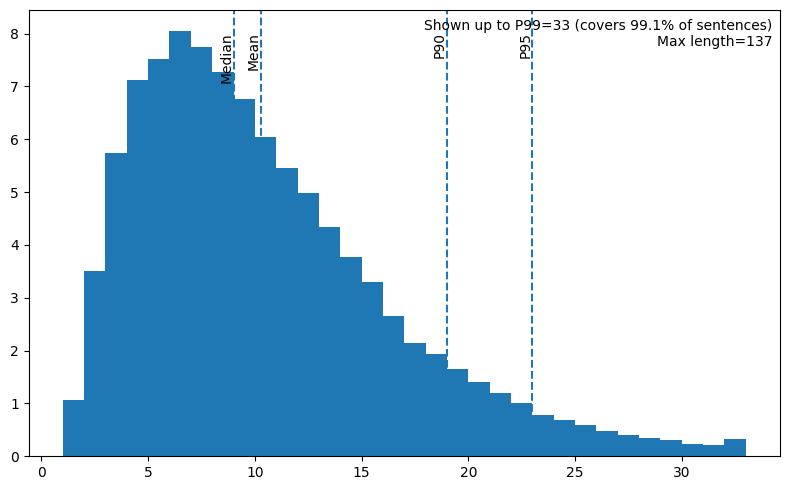

In [16]:
# ---- 2) Compute FD bins on the capped range ---------------------------------
cap = int(p99)  # show up to 99th percentile on the main axis
data_capped = lengths[lengths <= cap]
n = len(lengths)
iqr = np.subtract(*np.percentile(data_capped, [75, 25]))
# Freedman–Diaconis bin width (fallback if iqr=0)
bin_width = 2 * iqr * (len(data_capped) ** (-1/3)) if iqr > 0 else max(1, int(round(cap/50)))
num_bins = max(10, int(np.ceil((data_capped.max() - data_capped.min()) / max(1, bin_width))))
bins = np.linspace(data_capped.min(), data_capped.max(), num_bins + 1)

# ---- 3) Plot histogram (percentage) ------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
counts, edges, _ = ax.hist(
    data_capped,
    bins=bins,
    density=False,
    alpha=0.9
)
# Convert y-axis to percentage
pct = (counts / n) * 100.0
ax.cla()
ax.bar((edges[:-1] + edges[1:]) / 2, pct, width=np.diff(edges), align='center')

# Vertical markers
for val, label in [(median, "Median"), (mean, "Mean"), (p90, "P90"), (p95, "P95")]:
    ax.axvline(val, linestyle='--')
    ax.text(val, ax.get_ylim()[1]*0.95, label, rotation=90, va='top', ha='right')

# Coverage annotation
coverage = (data_capped.size / n) * 100
ax.text(0.99, 0.98,
        f"Shown up to P99={int(p99)} (covers {coverage:.1f}% of sentences)\nMax length={max_len}",
        transform=ax.transAxes, ha='right', va='top')

plt.tight_layout()
plt.show()

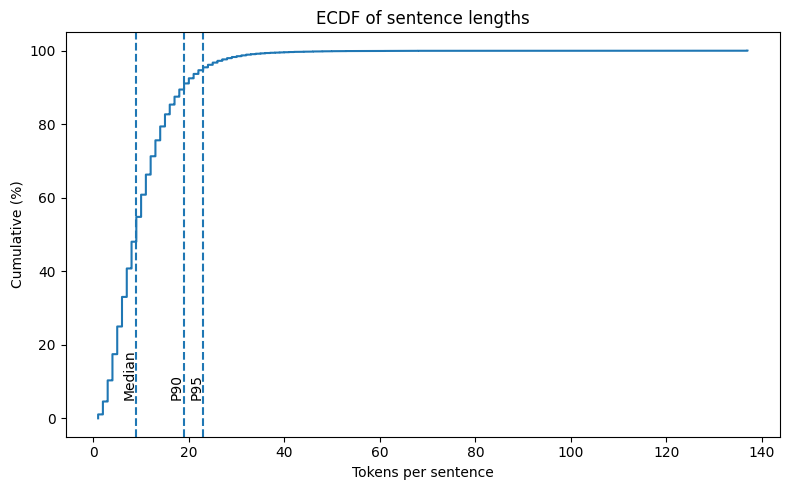

In [17]:
x = np.sort(lengths)
y = np.arange(1, n + 1) / n

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.step(x, y * 100.0, where='post')
ax2.set_xlabel("Tokens per sentence")
ax2.set_ylabel("Cumulative (%)")
ax2.set_title("ECDF of sentence lengths")
for val, label in [(median, "Median"), (p90, "P90"), (p95, "P95")]:
    ax2.axvline(val, linestyle='--')
    ax2.text(val, 5, label, rotation=90, va='bottom', ha='right')  # small y for label

plt.tight_layout()
plt.show()

In [2]:
import json
from collections import Counter

def load_tag_data():
    with open("tag_sentences.json", 'r', encoding='utf-8') as f:
        data = json.load(f)
        return data

tag_data = load_tag_data()
print(f"Loaded {len(tag_data)} tagged sentences")

Loaded 73313 tagged sentences


In [3]:
# Extract all entity labels from tag_sentence objects
all_labels = []
for item in tag_data:
    if 'tag_sentence' in item:
        for word, label in item['tag_sentence'].items():
            all_labels.append(label)

# Count frequency of each entity type
label_counts = Counter(all_labels)
print("Entity frequencies:")
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{label}: {count}")

Entity frequencies:
OTHERS: 649659
LOC: 16217
TIME: 15499
OBJECT: 13473
B-PER: 9872
B-ORG: 8366
E-ORG: 4162
E-PER: 4078
GARBAGE: 3392
I-PER: 2184
I-ORG: 2001
SKIP: 66


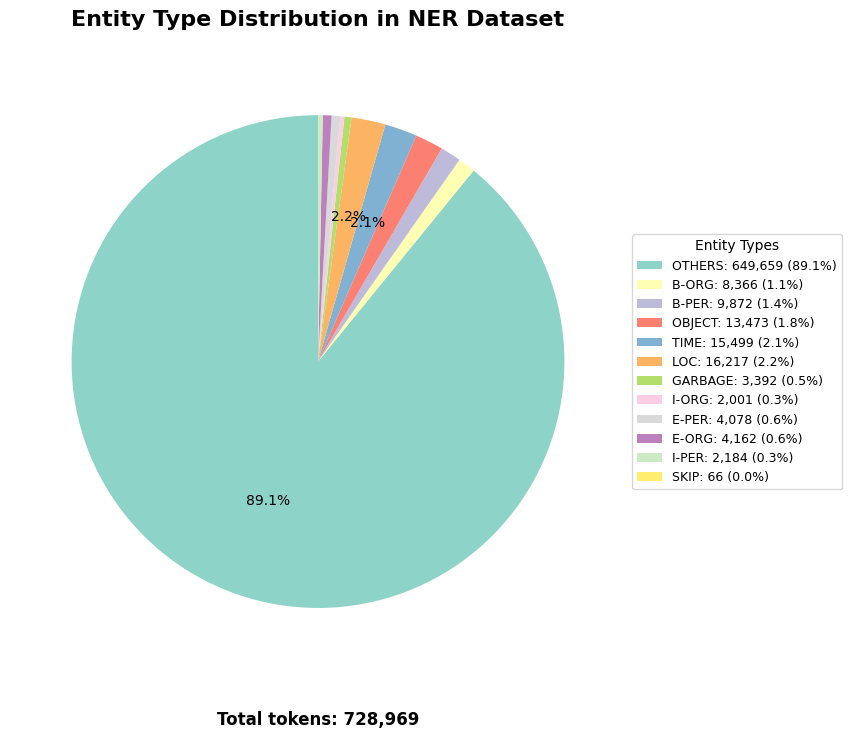

In [16]:
    # Create pie chart of entity frequencies
    labels = list(label_counts.keys())
    sizes = list(label_counts.values())
    total = sum(sizes)
    
    # Calculate percentages
    percentages = [(count/total)*100 for count in sizes]
    
    # Create color palette
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
    
    # Create the pie chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Only show percentages > 2% to avoid cluttered labels
    def autopct_format(pct):
       return f'{pct:.1f}%' if pct > 2 else ''
    
    wedges, texts, autotexts = ax.pie(sizes, labels=None, autopct=autopct_format,
                                     colors=colors, startangle=90, textprops={'fontsize': 10})
    
    ax.set_title('Entity Type Distribution in NER Dataset', fontsize=16, fontweight='bold', pad=20)
    
    # Add a legend with counts
    legend_labels = [f'{label}: {count:,} ({(count/total)*100:.1f}%)'
                   for label, count in zip(labels, sizes)]
    ax.legend(wedges, legend_labels, title="Entity Types",
             loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
    
    # Add total count annotation
    ax.text(0.5, -0.09, f'Total tokens: {total:,}', transform=ax.transAxes,
           ha='center', fontsize=12, fontweight='bold')
    
    # plt.tight_layout()
    plt.show()


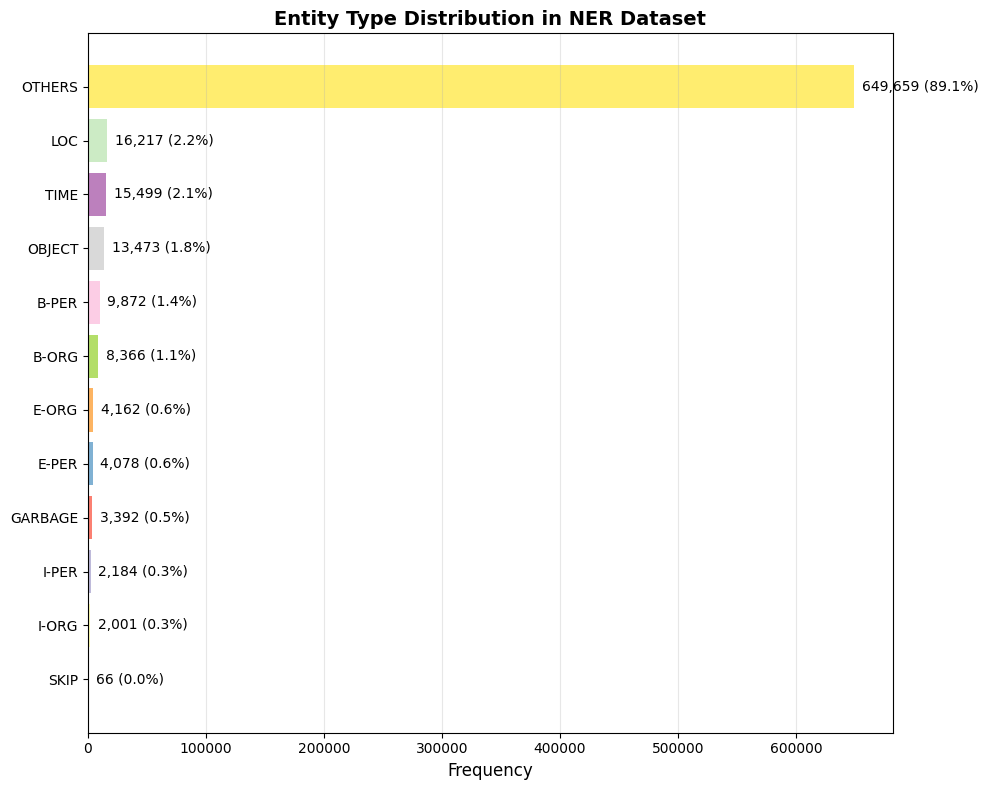

In [7]:
# Alternative: Horizontal bar chart for better readability
fig, ax = plt.subplots(figsize=(10, 8))

# Sort by frequency
sorted_items = sorted(label_counts.items(), key=lambda x: x[1])
labels_sorted = [item[0] for item in sorted_items]
counts_sorted = [item[1] for item in sorted_items]

# Create horizontal bar chart
bars = ax.barh(labels_sorted, counts_sorted, color=colors[:len(labels_sorted)])

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, counts_sorted)):
    ax.text(count + max(counts_sorted)*0.01, i, f'{count:,} ({(count/total)*100:.1f}%)', 
            va='center', fontsize=10)

ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Entity Type Distribution in NER Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Extract unique labels per sentence (only named entities)
sentence_labels = []
excluded_tags = {'OTHERS', 'GARBAGE', 'SKIP'}  # Tags to skip

for item in tag_data:
    if 'tag_sentence' in item:
        # Get unique labels for this sentence (excluding non-entity tags)
        unique_labels = set()
        for word, label in item['tag_sentence'].items():
            if label not in excluded_tags:
                # Clean up B-, I-, E- prefixes to get base entity types
                if label.startswith(('B-', 'I-', 'E-')):
                    base_label = label[2:]  # Remove prefix
                else:
                    base_label = label
                unique_labels.add(base_label)
        
        # Only include sentences with actual named entities
        if unique_labels:
            # Convert to list and sort for consistency
            sentence_labels.append(sorted(list(unique_labels)))

# Display first 20 examples
print("Labels per sentence (first 20):")
for i, labels in enumerate(sentence_labels[:20]):
    print(f"Sentence {i+1}: {labels}")

print(f"\nTotal sentences with entities: {len(sentence_labels)}")
print(f"Original total sentences: {len(tag_data)}")
print(f"Filtered out sentences: {len(tag_data) - len(sentence_labels)}")

# Save to JSON file
import json
with open('sentence_entity_labels.json', 'w', encoding='utf-8') as f:
    json.dump(sentence_labels, f, ensure_ascii=False, indent=2)
    
print(f"\nSaved to sentence_entity_labels.json")

Labels per sentence (first 20):
Sentence 1: ['ORG']
Sentence 2: ['OBJECT', 'PER']
Sentence 3: ['LOC', 'OBJECT', 'TIME']
Sentence 4: ['TIME']
Sentence 5: ['LOC']
Sentence 6: ['LOC', 'ORG']
Sentence 7: ['OBJECT']
Sentence 8: ['OBJECT']
Sentence 9: ['ORG']
Sentence 10: ['TIME']
Sentence 11: ['LOC']
Sentence 12: ['OBJECT', 'TIME']
Sentence 13: ['TIME']
Sentence 14: ['OBJECT']
Sentence 15: ['LOC', 'OBJECT', 'ORG', 'TIME']
Sentence 16: ['LOC']
Sentence 17: ['ORG']
Sentence 18: ['OBJECT', 'PER']
Sentence 19: ['TIME']
Sentence 20: ['OBJECT', 'TIME']

Total sentences with entities: 29647
Original total sentences: 73313
Filtered out sentences: 43666

Saved to sentence_entity_labels.json


In [22]:
# Verify the output format and show some statistics
print("\n=== Output Verification ===")
print(f"Sample format: {sentence_labels[:5]}")

# Count entity type combinations
from collections import Counter
combo_counts = Counter(tuple(labels) for labels in sentence_labels)
print(f"\nTop 10 most common entity combinations:")
for combo, count in combo_counts.most_common(10):
    print(f"  {list(combo)}: {count} sentences")

# Count individual entity types
all_entity_types = set()
for labels in sentence_labels:
    all_entity_types.update(labels)

print(f"\nUnique entity types found: {sorted(all_entity_types)}")
print(f"Total unique combinations: {len(combo_counts)}")

# Verify JSON file was created
import os
if os.path.exists('sentence_entity_labels.json'):
    print(f"\n✓ File successfully saved as sentence_entity_labels.json")
else:
    print(f"\n✗ Error: File was not saved")


=== Output Verification ===
Sample format: [['ORG'], ['OBJECT', 'PER'], ['LOC', 'OBJECT', 'TIME'], ['TIME'], ['LOC']]

Top 10 most common entity combinations:
  ['OBJECT']: 5051 sentences
  ['LOC']: 4723 sentences
  ['PER']: 4577 sentences
  ['TIME']: 3722 sentences
  ['ORG']: 3349 sentences
  ['LOC', 'TIME']: 1024 sentences
  ['LOC', 'ORG']: 835 sentences
  ['LOC', 'PER']: 798 sentences
  ['LOC', 'OBJECT']: 628 sentences
  ['ORG', 'TIME']: 619 sentences

Unique entity types found: ['LOC', 'OBJECT', 'ORG', 'PER', 'TIME']
Total unique combinations: 31

✓ File successfully saved as sentence_entity_labels.json


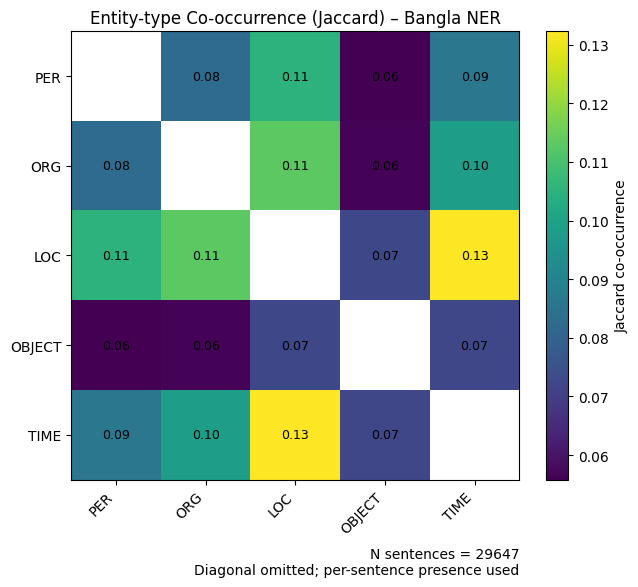

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, product

LABELS = ["PER","ORG","LOC","OBJECT","TIME"]

L = len(LABELS)
index = {lab:i for i,lab in enumerate(LABELS)}
pair_counts = np.zeros((L, L), dtype=int)
marginal = np.zeros(L, dtype=int)  # sentences containing label

for labs in sentence_labels:
    labs = set(labs) & set(LABELS)
    for lab in labs:
        marginal[index[lab]] += 1
    # add counts for unordered pairs within this sentence
    for a, b in combinations(sorted(labs), 2):
        i, j = index[a], index[b]
        pair_counts[i, j] += 1
        pair_counts[j, i] += 1

# Diagonal as marginal (optional – for a frequency map)
np.fill_diagonal(pair_counts, marginal)

N = len(sentence_labels)
marginal_p = marginal / N  # P(A)

# ---- 3A) JACCARD NORMALIZATION (MAIN HEATMAP RECOMMENDATION) ---------------
# Jaccard(A,B) = |A∩B| / |A∪B| with set-membership at sentence level.
jaccard = np.zeros((L, L), dtype=float)
for i, j in product(range(L), range(L)):
    inter = pair_counts[i, j] if i != j else marginal[i]  # but we will blank diag later
    union = marginal[i] + marginal[j] - (pair_counts[i, j] if i != j else marginal[i])
    jaccard[i, j] = inter / union if union > 0 else 0.0

# ---- 3B) PMI (OPTIONAL, AS A SECOND FIGURE) --------------------------------
# P(A,B) from off-diagonal pair_counts; diagonals undefined for PMI.
eps = 1e-9
pmi = np.zeros((L, L), dtype=float)
for i, j in product(range(L), range(L)):
    if i == j:
        pmi[i, j] = np.nan
    else:
        p_ab = pair_counts[i, j] / N
        pmi[i, j] = np.log((p_ab + eps) / ((marginal_p[i] * marginal_p[j]) + eps))

# ---- 4) PLOT JACCARD HEATMAP -----------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 6))
# Mask diagonal for display clarity
jaccard_disp = jaccard.copy()
for k in range(L): jaccard_disp[k, k] = np.nan

im = ax.imshow(jaccard_disp, aspect="equal")
ax.set_xticks(range(L)); ax.set_yticks(range(L))
ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_yticklabels(LABELS)

# Annotate cells with values (optional; keep 2 decimals)
for i in range(L):
    for j in range(L):
        if i == j or np.isnan(jaccard_disp[i, j]): 
            continue
        ax.text(j, i, f"{jaccard_disp[i, j]:.2f}", ha="center", va="center", fontsize=9)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Jaccard co-occurrence")

# Add note with corpus stats
ax.set_title("Entity-type Co-occurrence (Jaccard) – Bangla NER")
ax.text(1.0, -0.15,
        f"N sentences = {N}\nDiagonal omitted; per-sentence presence used",
        transform=ax.transAxes, ha="right", va="top")

plt.tight_layout()
plt.show()